# Getting Started with skyplothelper

**skyplothelper** turns astropy's WCS machinery into a one-import toolkit for
everyday sky figures: all-sky projections, zoomed fields, celestial globes,
and the grids, ticks, overlays, and annotations that go on top of them. This
first tutorial is the on-ramp — by the end you will be able to build a frame,
put your data on it, understand the handful of conventions that trip people
up, and know which of the later tutorials to reach for next.

We'll keep things deliberately broad and shallow here: every topic below has
a dedicated deep-dive tutorial, and we'll point you to it as we go.

> **New to `SkyCoord`, WCS, or matplotlib's `transform=`?** The
> [Foundations primer](../guide/foundations.md) is a short crash course in
> exactly those pieces — worth ten minutes if any of them are unfamiliar, and
> it makes everything below click.

## Contents

1. [Setup](#1.-Setup)
2. [A small example catalog](#2.-A-small-example-catalog)
3. [Your first frame](#3.-Your-first-frame)
4. [Your first all-sky map](#4.-Your-first-all-sky-map)
5. [Your first globes](#5.-Your-first-globes)
6. [Two conventions to know](#6.-Two-conventions-to-know)
7. [Working with coordinates](#7.-Working-with-coordinates)
8. [A first taste of decoration](#8.-A-first-taste-of-decoration)
9. [Themes and palettes](#9.-Themes-and-palettes)
10. [Getting the example data](#10.-Getting-the-example-data)
11. [Where to go next](#11.-Where-to-go-next)

## 1. Setup

The entire public API is re-exported at the top level, so a single import is
all you need. The convention throughout the docs is `import skyplothelper as
sph`. We also bring in numpy and matplotlib the usual way.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import skyplothelper as sph

That's it — no subpackage imports required. (The one exception is the
interactive plotly backend, conventionally `import skyplothelper.plotly as
sphpl`; see [Interactive Plotting with Plotly](interactive_plotly.ipynb).)

In [2]:
# One styling call up front, for a tightened, uniform look across every figure
# below. base='structural' adjusts only frame and tick *geometry* — inward ticks
# on all four sides, minor ticks, a quiet dotted grid, a slightly leaner spine —
# and touches no colors or fonts, so it composes cleanly with the light/dark page
# theme. It's the "base" layer of the styling system; Section 9 covers all three.
sph.set_style(base="structural")

### Finding your way around

There is a lot in here, and you are not expected to hold it in your head.
Two built-ins will tell you what's available without leaving your session:

- `sph.overview()` prints a one-screen orientation — what the package is for,
  the build-a-frame-then-draw-on-it workflow, and the conventions that most
  often trip people up on a first attempt.
- `sph.recipes()` lists task→code recipes by category. Pass a keyword —
  `sph.recipes("globes")`, `sph.recipes("stroke")` — and it prints runnable
  code for that task.

The recipe menu is worth a look right now, because it doubles as a map of
what this whole tutorial series covers:

In [3]:
sph.recipes()

30 recipes (call sph.recipes('<keyword>') for the code):

  all-sky frames:
    - Empty all-sky map with a coordinate grid
  catalogs:
    - Scatter a catalog on an all-sky map
    - Catalog scatter with color + size legends
    - Color stars by temperature (perceived color)
  overlays:
    - Overlay a second coordinate system's grid (e.g. galactic on ICRS)
    - Draw a great circle / plane on a sky frame
    - Reticle / crosshair on a target
    - Field-of-view / geodesic circle
    - Outline a region (spherical polygon)
    - Constellation stick figures
  images:
    - Quick-look a FITS image (contours/pixel map, beam, stats)
    - Show a FITS image on a WCS frame with a colorbar
    - Drape an RGB sky panorama onto a projection
    - Scale bar on an image
  globes:
    - Orthographic sky globe centered on a target
    - Globe of the Earth (or a planet)
    - Drape an Earth/planet texture onto a globe
    - Rotation-axis rod on an orthographic globe
  healpix:
    - Plot a sparse HEA

Notice the last category, **adjusting & legibility** — grid spacing, tick
label format, strokes for contrast, colorbars. Those cut across everything
else, and they answer the question that always follows "how do I plot this?",
namely "how do I make it *look* right?"

Smaller listings work the same way throughout the package:
`sph.list_projections()`, `sph.list_surveys()`, `sph.CYCLE_PALETTES`,
`sph.SEPARATORS`. When you can't remember what an option accepts, ask the
package.

## 2. A small example catalog

To have something to plot, let's set up a handful of famous objects. Real
positions arrive in all sorts of formats — decimal degrees from a FITS header,
a sexagesimal string copied out of a paper, galactic coordinates from a survey
— so rather than convert everything by hand, we hand each one to astropy's
`SkyCoord`, which speaks all of these dialects. Each entry below uses a
different input style, so you can pick whichever matches the data you have:

In [4]:
import astropy.units as u
from astropy.coordinates import SkyCoord

sources = {
    # Decimal degrees — the workhorse. `unit=` says how to read the numbers.
    "M31 (Andromeda)":  SkyCoord(10.6847, 41.2687, unit="deg"),

    # Numbers that already carry their units — then no `unit=` is needed.
    "M45 (Pleiades)":   SkyCoord(ra=56.75 * u.deg, dec=24.1167 * u.deg),

    # One sexagesimal string, the way most papers quote a position.
    "M1 (Crab)":        SkyCoord("05h34m31.94s +22d00m52.2s"),

    # Sexagesimal split into two fields — RA in hours, Dec in degrees.
    "M42 (Orion Neb.)": SkyCoord("05 35 17.3", "-05 23 28",
                                 unit=(u.hourangle, u.deg)),

    # Defined in a different frame, then converted: Sgr A* is most naturally
    # quoted in galactic coordinates, and `.icrs` hands back the equatorial form.
    "Sgr A*":           SkyCoord(l=359.9442 * u.deg, b=-0.0461 * u.deg,
                                 frame="galactic").icrs,

    # Looked up from skyplothelper's built-in table of common targets.
    "LMC":              sph.SKY_POSITIONS["lmc"],

    # ...and plain decimal degrees for the rest.
    "M13 (Hercules)":   SkyCoord(250.4234, 36.4613, unit="deg"),
    "Vega":             SkyCoord(279.2347, 38.7837, unit="deg"),
}

# Gather the individual positions into one array-valued SkyCoord, and pull out
# plain degree arrays alongside it.
names   = list(sources)
catalog = SkyCoord([sources[n] for n in names])
ra, dec = catalog.ra.deg, catalog.dec.deg

print(f"{len(catalog)} sources. First three, in degrees:")
for n, c in zip(names[:3], catalog[:3]):
    print(f"  {n:18} {c.ra.deg:9.4f}  {c.dec.deg:9.4f}")

8 sources. First three, in degrees:
  M31 (Andromeda)      10.6847    41.2687
  M45 (Pleiades)       56.7500    24.1167
  M1 (Crab)            83.6331    22.0145


**One object, not eight.** That last step is worth a moment. Passing a
*list* of coordinates to `SkyCoord([...])` folds them into a single **array-valued**
`SkyCoord` — the natural container for a catalog, not eight separate objects.
It behaves like an array: index it (`catalog[0]`), slice it (`catalog[:3]`),
and read its attributes back vectorized (`catalog.ra.deg` is an eight-element
array), exactly as the loop above does. You needn't assemble it from scalars,
either — handing `SkyCoord` two whole columns of numbers builds the same thing
in one call:

```python
catalog = SkyCoord(ra, dec, unit="deg")   # ra, dec: matching arrays of degrees
```

Either way, that one object is all the plotting helpers need — from Section 4
on we hand this `catalog` straight to `plot_catalog` and `sph.scatter`.

## 3. Your first frame

Every skyplothelper plot starts from a **frame**: a matplotlib axes wired to a
world coordinate system, so that sky positions land where the projection says
they should. Under the hood a frame is a real astropy `WCSAxes` — anything you
could do with WCSAxes, you can do here too.

The master builder is `make_wcs_frame()`. For a zoomed-in
field we pick a tangent-plane projection (`"TAN"`, the gnomonic projection
used for most imaging), a center, and a field of view in degrees. Let's frame
a few-degree patch around the Orion Nebula and drop our objects onto it.

To put data on a frame, reach for skyplothelper's plotting helpers —
`sph.scatter`, `sph.plot`, `sph.text`, and friends. They take sky coordinates
(a `SkyCoord`, or plain RA/Dec in degrees) and place them for you:

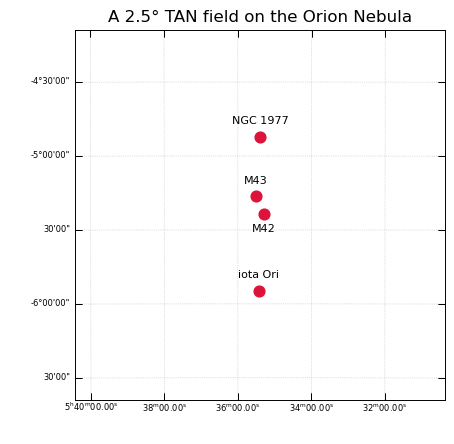

In [5]:
# A few real objects in the Orion Nebula neighborhood
orion = {
    "M42":      (83.8221, -5.3911),
    "M43":      (83.8800, -5.2700),
    "NGC 1977": (83.8500, -4.8700),
    "iota Ori": (83.8584, -5.9099),
}
o_ra  = np.array([v[0] for v in orion.values()])
o_dec = np.array([v[1] for v in orion.values()])

ax = sph.make_wcs_frame(111, "TAN", center=(83.85, -5.4), fov_deg=2.5)
sph.scatter(ax, o_ra, o_dec, s=60, color="crimson", zorder=5)
for label, (x, y) in orion.items():
    # M43 sits just north of M42, so nudge M42's label below its dot instead
    dy, va = (-0.07, "top") if label == "M42" else (0.07, "bottom")
    sph.text(ax, x, y + dy, label, ha="center", va=va, fontsize=8)
ax.set_title("A 2.5° TAN field on the Orion Nebula")
plt.show()

Two things worth noticing:

- **The data went on in one call, in sky coordinates.** `sph.scatter` and
  `sph.text` take RA/Dec straight (specified in degrees) and place each point
  where the projection says it goes — no bookkeeping on your end.
  These are the everyday way to draw on a frame;
  Section 4 lays out the full family and shows a case where they do something a
  plain matplotlib call can't.
- **The axes are already decorated for legibility.** `make_wcs_frame` gave us
  a coordinate grid and formatted RA/Dec tick labels for free. All of that is
  tunable — see [Decorating Frames](decorating_frames.ipynb).

For zoomed fields — a single source, say — you'll often want
*offset* (relative) coordinates instead of absolute RA/Dec — arcseconds from a
target, for example. The convenience builder
`offset_figure()` does exactly that in one call; we'll meet it again in
[A Tour of Projections](projections.ipynb) and
[Decorating Frames](decorating_frames.ipynb).

### Coming from matplotlib?

A frame is a real `WCSAxes`, so every matplotlib method still works on it
directly — you just have to tell matplotlib that your numbers are world (sky)
coordinates, by passing `transform=ax.get_transform("world")`. The same figure
as above but using the longer matplotlib way of explicitly setting the transform
is:

```python
ax.scatter(o_ra, o_dec, transform=ax.get_transform("world"),
           s=60, color="crimson", zorder=5)
ax.text(x, y, label, transform=ax.get_transform("world"), ha="center")
```

That `world` transform is exactly what the `sph.*` helpers apply for you, and
it's worth seeing once because it works for *any* matplotlib function — even
ones skyplothelper doesn't wrap. So keep it in your back pocket for those, and
reach for the `sph.*` helpers (Section 4) the rest of the time. The
[Foundations primer](../guide/foundations.md) unpacks what the transform
actually is.

## 4. Your first all-sky map

To show the *whole* sky we switch to an all-sky projection. The
`allsky_figure()` convenience builder makes the figure and
an elliptical frame together and returns `(fig, ax)`. The default is the
Hammer–Aitoff projection (`"AIT"`), an equal-area oval — a good default
all-sky map. `center=` sets the longitude at the middle of the map.

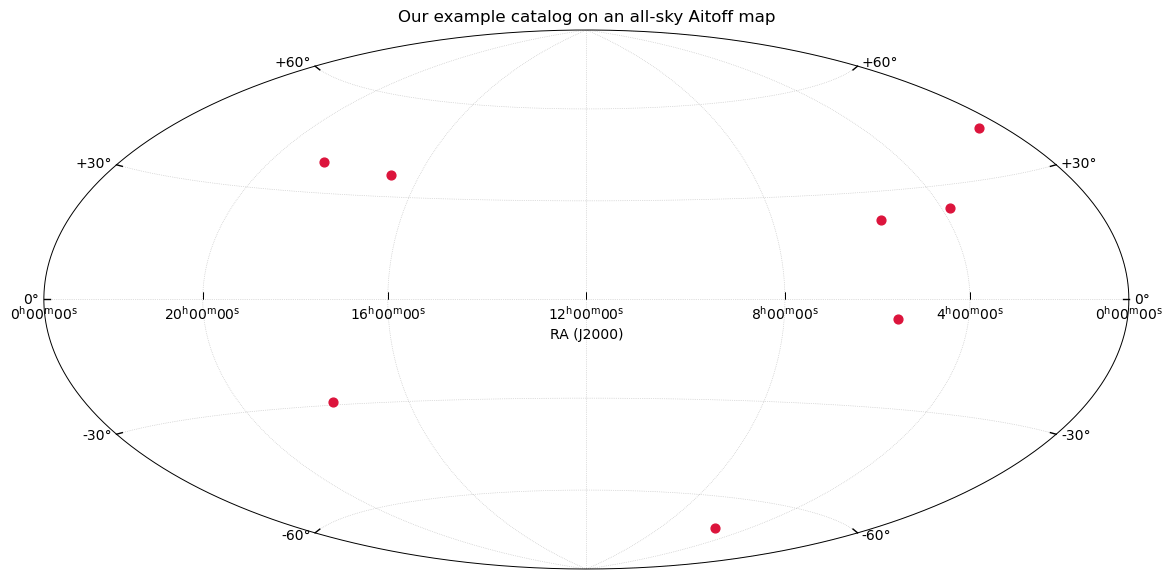

In [6]:
fig, ax = sph.allsky_figure(projection="AIT", center=180)
sph.scatter(ax, ra, dec, s=40, color="crimson", zorder=5)
ax.set_title("Our example catalog on an all-sky Aitoff map")
plt.show()

Same `sph.scatter` call as the Orion field — only the frame changed, so the
other sources are now visible too. Try
swapping `projection="AIT"` for `"MOL"` (Mollweide) or `"SFL"`
(Sanson–Flamsteed) to see other equal-area all-sky maps. The full projection
zoo, and how to choose among ~30 of them, is the subject of
[A Tour of Projections](projections.ipynb); `sph.list_projections()` prints
the registry any time.

### The full family of shortcuts

`sph.scatter` is one of a set that mirrors the everyday matplotlib calls,
each applying the `world` transform for you and accepting either a `SkyCoord`
or plain degrees:

| Helper(s) | What it draws |
|---|---|
| `sph.scatter` | points |
| `sph.plot`, `sph.step` | connected lines (split at the seam) |
| `sph.fill`, `sph.fill_between` | filled regions |
| `sph.errorbar` | points with error bars |
| `sph.text`, `sph.annotate` | text labels |
| `sph.contour`, `sph.pcolormesh`, `sph.hist2d` | gridded / density data |

Each also has a method form on frames skyplothelper builds —
`ax.sky_scatter(...)` is the same call as `sph.scatter(ax, ...)`.

These skyplothelper versions of those familiar tools are more than a convenience,
though: they fix a real issue you may encounter on sky plots that the raw mpl
call doesn't handle well. A path that crosses the map's antimeridian (or "seam"
as it's called colloquially here) — the left/right edge, at
RA 0ʰ on a map centered at 12ʰ — is drawn by matplotlib as a straight line in
*pixel* space, so it streaks back across the whole figure. `sph.plot` splits
the path at the seam instead:

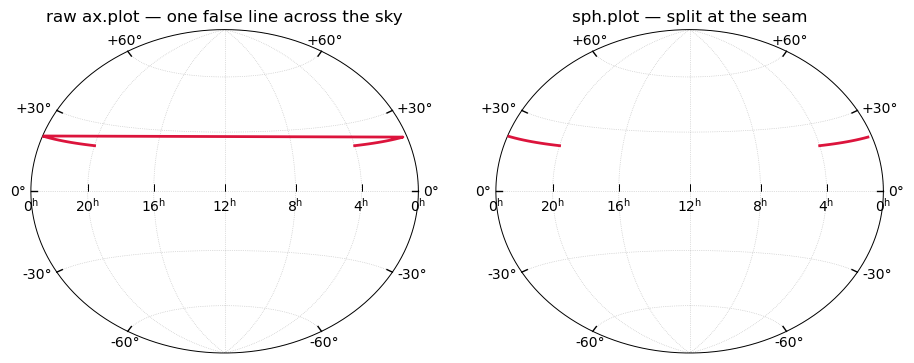

In [7]:
# A track sweeping through RA 0ʰ. The longitudes run on past 360° rather than
# wrapping back to 0, which is what keeps the path continuous across the seam —
# wrap it to 0 and each half stops at its last point short of the frame edge.
lon = np.arange(300., 421., 5.)
lat = np.full_like(lon, 20.)

fig = plt.figure(figsize=(11, 4.2))

ax1 = sph.make_wcs_frame(121, "AIT", center=180, npix=(600, 300))
ax1.plot(lon, lat, transform=ax1.get_transform("world"), color="crimson", lw=2)
ax1.set_title("raw ax.plot — one false line across the sky")

ax2 = sph.make_wcs_frame(122, "AIT", center=180, npix=(600, 300))
sph.plot(ax2, lon, lat, color="crimson", lw=2)
ax2.set_title("sph.plot — split at the seam")

plt.show()

Same points both times. Only the right-hand panel properly transitions to the
other side without drawing across the entire frame once it hits the edge.

### The catalog-aware step up: `plot_catalog`

For catalogs specifically there's one more rung. `plot_catalog()` takes your
data roughly as you already have it — an astropy `Table`, a pandas `DataFrame`,
a dict of columns, bare `(lon, lat)` arrays, or a `SkyCoord` — and works out the
coordinates itself. Our `catalog` from Section 2 is a `SkyCoord`, so it goes
straight in, with no `.ra.deg` / `.dec.deg` unpacking:

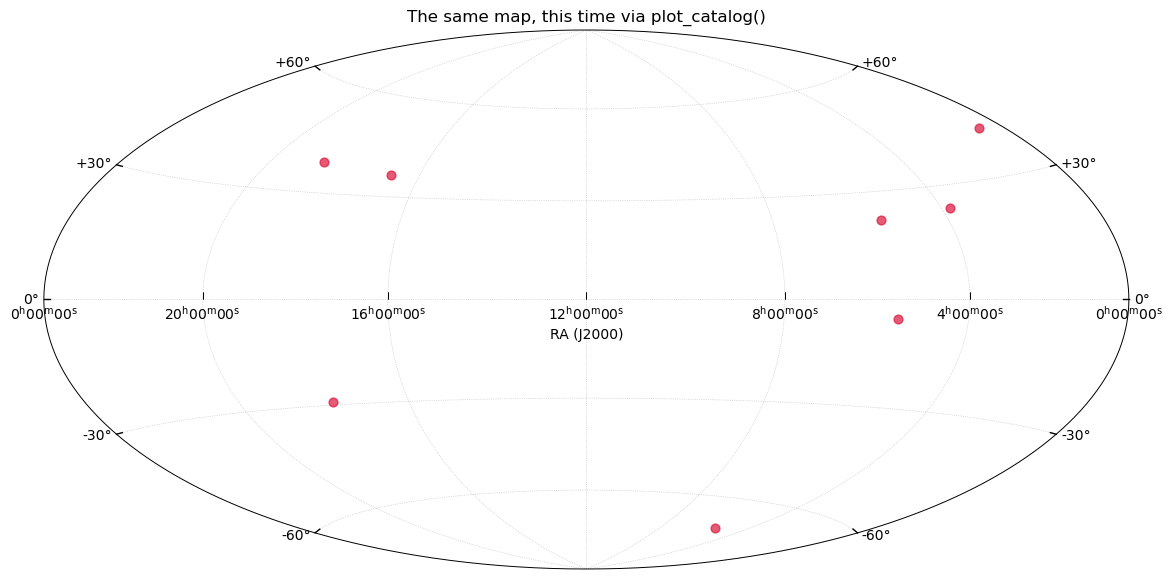

In [8]:
fig, ax = sph.allsky_figure(projection="AIT", center=180)
sph.plot_catalog(ax, catalog, color="crimson", s=40)
ax.set_title("The same map, this time via plot_catalog()")
plt.show()

The same figure, with no transform bookkeeping and no unpacking. And because it
knows it's drawing a *catalog*, it can do things a bare `scatter` can't: scale
the marker size or color by any column (with a matching colorbar and size
legend), label the points, or convert from another coordinate frame on the way
in — we'll use that last one in Section 7. [Catalogs — Querying, Plotting and
Searching](catalogs.ipynb) is the full tour.

So there are three rungs, and all three are worth having:

| Reach for | When |
|---|---|
| `ax.scatter(..., transform=...)` | you want raw matplotlib control, or a call skyplothelper doesn't wrap |
| `sph.scatter` / `sph.plot` / … | everyday plotting — the transform and the seam are handled |
| `sph.plot_catalog` | a catalog, especially one you want to encode by column |

## 5. Your first globes

A flat all-sky map shows everything at once, at the price of distortion. A
**globe** makes the opposite trade: you only see the hemisphere facing you,
but it looks like what it is — a sphere. (Both globes below are orthographic
views — projection code `SIN` — the sphere as seen from very far away.)

There are two builders. They work the same way, and differ in one detail
that's worth seeing for yourself:

- `make_globe_frame()` — a **sky** globe, in celestial coordinates.
- `make_planet_frame()` — a **planet** globe, on a body-fixed surface frame.

Here they are side by side: our catalog on a sky globe, and a handful of
radio observatories on Earth.

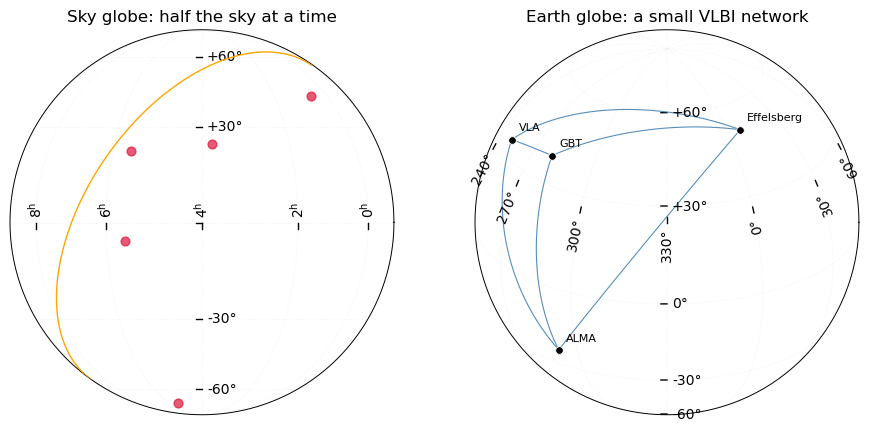

In [9]:
fig = plt.figure(figsize=(11, 5))

# A sky globe, centered near Orion
ax1 = sph.make_globe_frame(121, center_LONdeg=60, center_LATdeg=0)
sph.add_plane_overlay(ax1, plane="galactic", color="orange")
sph.plot_catalog(ax1, catalog, color="crimson", s=40, zorder=5)
ax1.set_title("Sky globe: half the sky at a time")

# An Earth globe, with the baselines of a small VLBI network
sites = {
    "VLA":        (-107.618,  34.079),
    "GBT":        ( -79.840,  38.433),
    "ALMA":       ( -67.755, -23.029),
    "Effelsberg": (   6.883,  50.525),
}
ax2 = sph.make_planet_frame(122, body="earth", center_LONdeg=-30, center_LATdeg=25)
sph.plot_baselines(ax2, sites)
ax2.set_title("Earth globe: a small VLBI network")

plt.show()

Only the near side is drawn: three of our eight sources sit on the far side of
the sky globe and aren't shown — the data plotters drop points that fall behind
the limb, and `plot_baselines()` clips its arcs the same way for stations around
the back. Showing the far side is a job for the decorations that carry geometry
across the limb: `highlight_great_circle()` traces a full ring with its far half
dashed, and `plot_baselines()` can fade the back-hemisphere stations instead of
culling them. [Globe and Planet Plotting](globe_plots.ipynb) has the full story.
(The orange arc is the Galactic plane, drawn with `add_plane_overlay()` — one of
the decoration helpers we'll sample in Section 8.)

**The difference to notice is in the longitude labels.** Read along the
equator of each globe: on the sky globe they run 8ʰ, 6ʰ, 4ʰ, 2ʰ, 0ʰ from left
to right, so right ascension *increases to the left*. On the Earth globe they
run 240°, 270°, 300°, 330°, 0°, so longitude *increases to the right*. That
is the astronomical-versus-geographic convention, and it's the first thing we
unpack in the next section.

Everything else about globes — tilting a planet to its obliquity, draping
textures and survey imagery, day/night terminators, rotation-axis rods, and
spinning the whole thing into an animation — is in
[Globe and Planet Plotting](globe_plots.ipynb).

## 6. Two conventions to know

A handful of defaults run through *every* frame builder. Two of them cause
most early confusion, so let's get them out of the way now. (The full set
lives in the [Core concepts](../guide/concepts.md) guide page.)

### Longitude runs east-left (the astronomical convention)

Looking *up* at the sky with north up, east is to the **left**. Looking *down*
at the Earth, east is to the right. skyplothelper is an astronomy-focused
package, so almost every frame defaults to the sky convention:

- `direction='sky'` (aliases `'astro'`, `'east-left'`) — the default.
- `direction='geo'` (aliases `'earth'`, `'east-right'`) — for Earth/planet maps.

> **Important:** If an Earth or planet map ever looks mirrored, **this** is
> why — and the fix is *not* to flip the axis by hand. Pass `direction='geo'`,
> or better, use `make_planet_frame()` (Section 5), which bundles the
> geographic direction with the body-fixed coordinate frame. The full story is in
> [Globe and Planet Plotting](globe_plots.ipynb).

### The frame's coordinate system is ICRS by default

`frame='ICRS'` (J2000 equatorial) is the default. `'galactic'`, `'ecliptic'`,
and `'supergalactic'` are accepted anywhere a frame is built. This sets the
coordinate system *of the frame itself* — its gridlines, its tick labels, and
what your `(lon, lat)` inputs mean. Converting your data between systems is a
separate, explicit step, which is exactly what we do next.

## 7. Working with coordinates

Almost every plot starts from coordinates, so it's worth a moment on how to
*get them into the form a frame wants*. For serious coordinate work,
skyplothelper doesn't reinvent the math — it leans on astropy's `SkyCoord`. You
convert your data, then hand the converted longitude/latitude to a frame built
in that system.

Our catalog is already a `SkyCoord` (Section 2), so expressing it in Galactic
coordinates is a single attribute access:

In [10]:
gal = catalog.galactic
print(f"{'object':18}  {'l (deg)':>9}  {'b (deg)':>9}")
for n, c in zip(names, gal):
    print(f"{n:18}  {c.l.deg:9.3f}  {c.b.deg:9.3f}")

object                l (deg)    b (deg)
M31 (Andromeda)       121.174    -21.573
M45 (Pleiades)        166.571    -23.521
M1 (Crab)             184.557     -5.784
M42 (Orion Neb.)      209.014    -19.382
Sgr A*                359.944     -0.046
LMC                   280.465    -32.888
M13 (Hercules)         59.009     40.912
Vega                   67.448     19.237


Now build a **galactic-frame** all-sky map and plot the *galactic* longitude
and latitude on it. The objects land in the same physical places on the sky;
only the gridlines and labels now read in galactic coordinates, and the
Galactic plane runs horizontally across the middle.

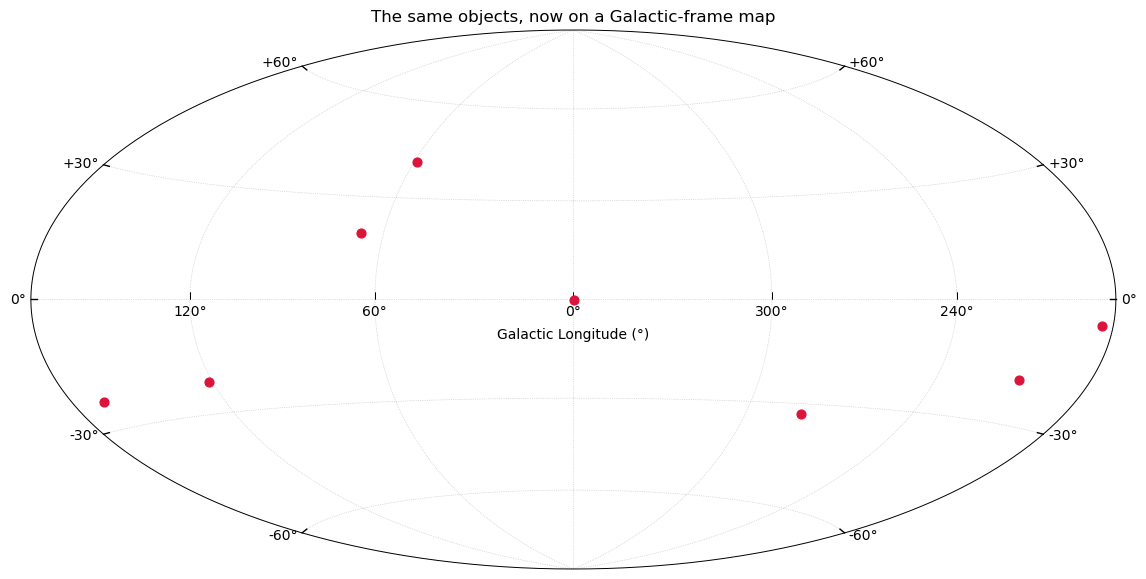

In [11]:
fig, ax = sph.allsky_figure(projection="AIT", center=0, frame="galactic")
ax.scatter(gal.l.deg, gal.b.deg, transform=ax.get_transform("world"),
           s=40, color="crimson", zorder=5)
ax.set_title("The same objects, now on a Galactic-frame map")
plt.show()

Notice where **Sgr A\*** landed: essentially dead center. The radio source at
the heart of the Milky Way sits about 4 arcminutes from galactic
`(l, b) = (0°, 0°)` — not by coincidence, but because the galactic coordinate
system was *defined* with its origin pointing at the galactic center. Seeing a
familiar object land where it belongs is a quick, cheap check that a
conversion did what you expected.

The rule of thumb: **convert first, then plot in the frame's own system.** If
you build a galactic frame but hand it raw equatorial coordinates, your points
will land in the wrong place — a common and quietly confusing slip.

### Or let the plotting call convert for you

That explicit conversion is worth understanding, since it's what's happening
underneath. But for the everyday case you can skip it. A `SkyCoord` already
knows which frame it's in, so handing one to `plot_catalog()` is enough — it
converts onto whatever frame the axes uses, with nothing for you to declare.
Our `catalog` is still equatorial; the map below is galactic:

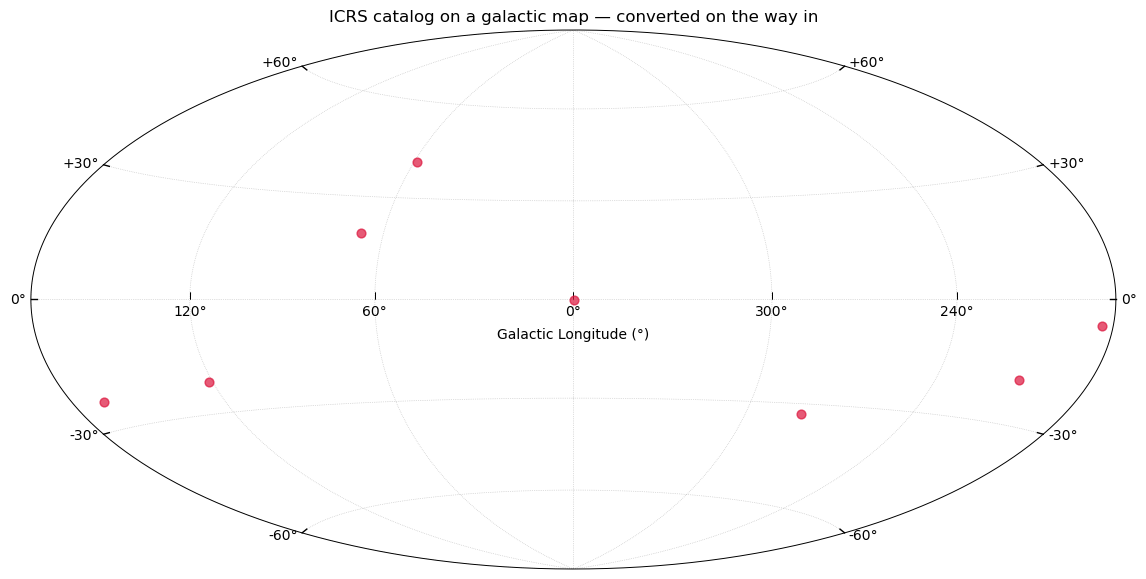

In [12]:
fig, ax = sph.allsky_figure(projection="AIT", center=0, frame="galactic")
sph.plot_catalog(ax, catalog, color="crimson", s=40)
ax.set_title("ICRS catalog on a galactic map — converted on the way in")
plt.show()

Identical to the previous figure — and we never converted anything ourselves.
That's the pattern to remember: understand the explicit route, then let the
helper carry it for you. (A plain column catalog — a `Table` or a dict — has no
frame attached to carry, so there you tell `plot_catalog` what it's in with
`frame="icrs"`.)

### Lightweight coordinate helpers

`SkyCoord` is the right tool for heavy lifting, but for quick jobs skyplothelper
also ships a few conveniences that take and return plain numbers/arrays — no
`SkyCoord` ceremony:

- **Frame conversion** — `convert_frame(lon, lat, from_frame=, to_frame=)` is
  the general one-liner, with named shortcuts (`icrs_to_galactic`,
  `galactic_to_icrs`, `icrs_to_ecliptic`, `icrs_to_supergalactic`, …).
- **Sexagesimal ↔ decimal** — `dec2sex`/`sex2dec` handle an RA/Dec pair at once;
  `deg2hour`/`hour2deg` and `deg2dms`/`dms2deg` do one axis.
- **Known positions** — `SKY_POSITIONS` is a dict of common targets
  (`'galactic_center'`, `'m31'`, `'lmc'`, `'virgo_cluster'`, …) as ready
  `SkyCoord`s, so you needn't look them up.
- **Angular separation** — `angulardistance(coord1, coord2)`.

In [13]:
# Array-in, array-out frame conversion (no SkyCoord object needed):
l_arr, b_arr = sph.convert_frame(ra, dec, from_frame="icrs", to_frame="galactic")
print("galactic center ->", [round(v, 2) for v in sph.icrs_to_galactic(266.417, -28.936)])

# Sexagesimal <-> decimal (RA in hours, Dec in degrees):
print("Crab in sexagesimal:", sph.dec2sex(83.6287, 22.0147, as_string=True))
print("...and back to decimal:", [round(v, 4) for v in sph.sex2dec("05:34:31.0", "+22:00:53")])

# Grab known targets and measure a separation:
m31, m33 = sph.SKY_POSITIONS["m31"], sph.SKY_POSITIONS["m33"]
sep = sph.angulardistance((m31.ra.deg, m31.dec.deg), (m33.ra.deg, m33.dec.deg))
print(f"M31 at ({m31.ra.deg:.2f}, {m31.dec.deg:.2f}); M31–M33 separation {sep:.1f}°")

galactic center -> [0.01, -0.01]
Crab in sexagesimal: ['05:34:30.89', '22:00:52.92']
...and back to decimal: [83.6292, 22.0147]
M31 at (10.69, 41.27); M31–M33 separation 14.8°


Use whichever fits the moment — `SkyCoord` for rigor and round-trips, these
helpers for a quick conversion, a sexagesimal label, or a known target.

## 8. A first taste of decoration

Most of skyplothelper is helpers that *add* things to a frame. Here's a quick
sampler; each has a dedicated tutorial with the full set of options.

- `add_plane_overlay()` — draw a reference plane (galactic,
  ecliptic, ...) as a line or shaded band.
- `add_survey_footprint()` — shade the sky coverage of a
  known survey (`sph.list_surveys()` lists them).
- `format_ticklabels()` — restyle the RA/Dec tick labels,
  including how the RA "hours" are rendered.

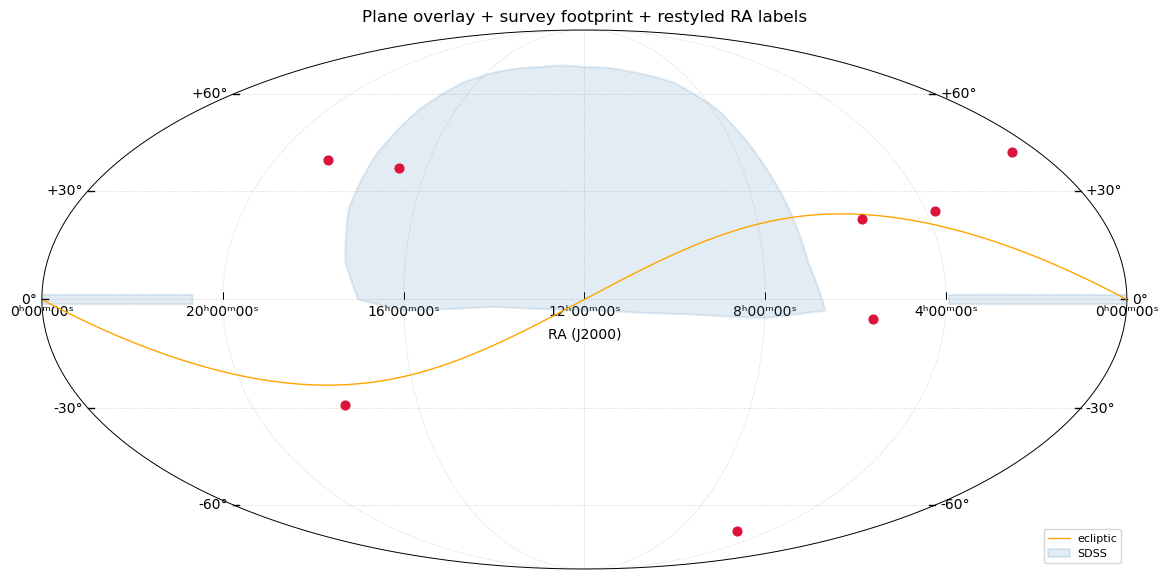

In [14]:
fig, ax = sph.allsky_figure(projection="MOL", center=180)

# A reference plane and a survey footprint
sph.add_plane_overlay(ax, plane="ecliptic", color="orange", label="ecliptic")
sph.add_survey_footprint(ax, survey="sdss", color="steelblue", label="SDSS")

# Our catalog on top
sph.scatter(ax, catalog, s=40, color="crimson", zorder=5)

# Render RA hours with unicode superscripts (ʰ ᵐ ˢ)
sph.format_ticklabels(ax, ra_sep="hms_unicode")

ax.legend(loc="lower right", fontsize=8)
ax.set_title("Plane overlay + survey footprint + restyled RA labels")
plt.show()

A few pointers to the deep dives:

- Grids, tick styles (absolute / offset / VLBI), edge-vs-in-frame ticks, and
  the RA-hours separators (`sph.SEPARATORS` is the inspectable menu) →
  [Decorating Frames](decorating_frames.ipynb).
- Beams, scale bars, compasses, rulers, reticles, colorbars →
  [Annotations & Overlays](annotations.ipynb).
- Zoom insets with connector lines →
  [Insets and Zoom Axes](insets_and_zoom.ipynb).
- Survey footprints as *geometry* (membership tests, set algebra) →
  [Regions & Spherical Polygons](regions.ipynb).
- Constellation boundaries, asterisms, and labels →
  [Constellations and Asterisms](constellations.ipynb).

## 9. Themes and palettes

skyplothelper ships a small styling system on top of matplotlib's rcParams,
with three composable layers:

- **base** (`set_base_style()`) — structural rcParams: ticks, spines, grid,
  fonts, sizes (presets like `'structural'`, `'journal'`, `'poster'`).
- **theme** (`set_theme()`) — a coherent visual look
  (`'publication'`, `'twilight'`, `'dark_sky'`, `'poster'`).
- **palette** (`set_palette()`) — the color cycle
  (`sph.CYCLE_PALETTES` lists them, e.g. `'uranometria'`, `'nightcap'`).

`set_style()` sets any combination in one call — it's the call we made back in
Section 1 (`base='structural'`), which is where every figure's inward ticks and
tightened frame come from. On top of that these tutorials render with the light
`publication` theme, but nothing stops you from trying another look right now —
there are two ways in:

- **Scoped preview** — `style_context()` applies a look only *inside a `with`
  block*, then restores everything on exit. Perfect for notebooks, since no
  other cell is affected.
- **Session-wide** — `set_style()` changes the global settings, so every
  figure you make afterward picks up the look; call it once at the top of
  your own scripts.

Here is the same catalog map wearing the `dark_sky` theme and the `nightcap`
color cycle, scoped so the rest of this notebook keeps its usual theme:

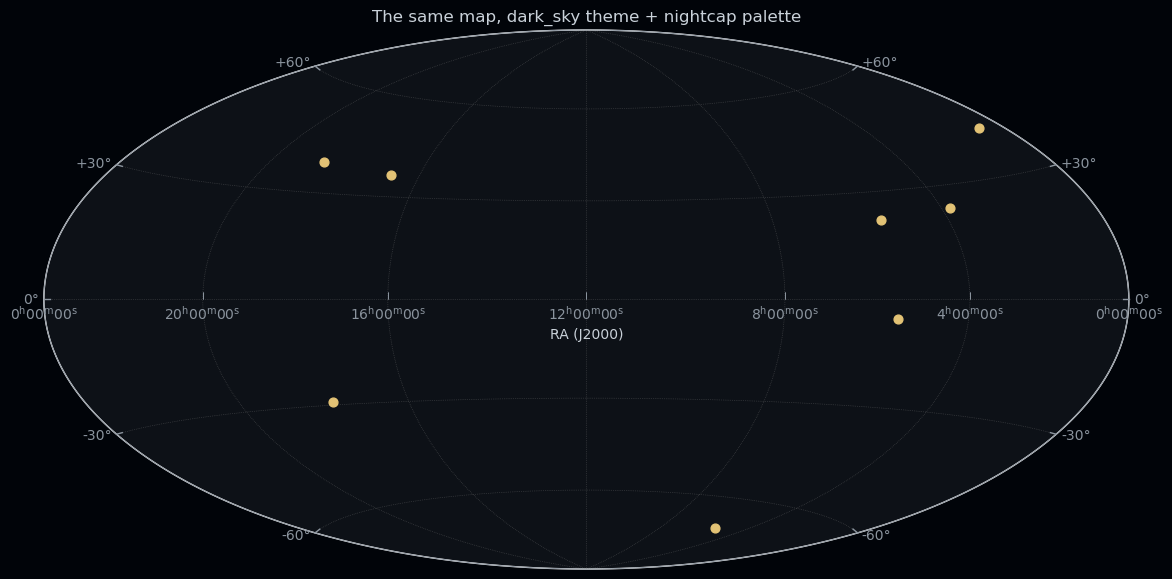

In [15]:
with sph.style_context(theme="dark_sky", palette="nightcap"):
    fig, ax = sph.allsky_figure(projection="AIT", center=180)
    sph.scatter(ax, catalog, s=40, zorder=5)
    ax.set_title("The same map, dark_sky theme + nightcap palette")
    plt.show()

(Note we didn't pass a `color=` this time — the points simply take the first
color of the active `nightcap` cycle.)

> **Note:** to flip your *whole session* instead, uncomment the cell below and
> re-run any earlier cell to see it restyled. Restore the light look with
> `sph.set_style(theme="publication")` when you're done.

In [16]:
# --- Switch the whole session to a dark look (uncomment to try) ---
# sph.set_style(theme="dark_sky", palette="nightcap")

The full styling tour — the three layers in depth, every theme and palette,
annotation palettes for finder charts, portable font stacks, and building a
reusable house style — is [Themes, Palettes & Fonts](styling.ipynb).
Frame-specific looks (tick styles, grid styling, and themes on sky frames)
live in [Decorating Frames](decorating_frames.ipynb).

## 10. Getting the example data

The later tutorials draw on a small set of reference datasets: real catalogs
(the ICRF3 defining quasars, the Messier list, Hipparcos proper motions, a
2dFGRS redshift slice), science FITS images (VLBA quasar jets, the Crab
Nebula and NGC 602 in several bands, an HI data cube), and imagery (all-sky
panoramas, Earth and planet textures, marker icons). They live in the
project's
[`examples/data/`](https://github.com/pjcigan/skyplothelper/tree/main/examples/data)
directory rather than in the pip install — grab them from the repository,
except for the large raster maps, which are fetched from their original
providers (the
[`examples/data/README.md`](https://github.com/pjcigan/skyplothelper/tree/main/examples/data)
lists every file with its source, license, and download link, and the
[installation guide](../installation.md) has the details).

Nothing in *this* tutorial needs them — everything above runs with just
skyplothelper, numpy, matplotlib, and astropy.

## 11. Where to go next

You now know the core loop: **build a frame → put data on it with the `world`
transform → decorate → style.** From here, pick the deep-dive that matches
what you're making — this is the full series:

| If you want to... | Go to |
|---|---|
| Compare projections and put images on the sky | [A Tour of Projections](projections.ipynb) |
| Fine-tune grids, ticks, and labels | [Decorating Frames](decorating_frames.ipynb) |
| Overlay a second coordinate system | [Overlay Coordinate Grids](overlay_grids.ipynb) |
| Display and stretch FITS images | [FITS Images & Quicklook](fits_images.ipynb) |
| Add beams, scale bars, compasses, rulers, reticles | [Annotations & Overlays](annotations.ipynb) |
| Build and combine sky regions | [Regions & Spherical Polygons](regions.ipynb) |
| Add zoom insets with connector lines | [Insets and Zoom Axes](insets_and_zoom.ipynb) |
| Bin, query, and map HEALPix data | [HEALPix Workflows](healpix_workflows.ipynb) |
| Make redshift-wedge and bowtie diagrams | [Cone & Bowtie Plots](cone_bowtie.ipynb) |
| Draw globes and tilted planets | [Globe and Planet Plotting](globe_plots.ipynb) |
| Place telescope, dome, or planet image markers | [Markers — Rotatable and Image Stamps](markers.ipynb) |
| Query SIMBAD/NED/VizieR and plot catalogs | [Catalogs — Querying, Plotting and Searching](catalogs.ipynb) |
| Plot proper motions and vector fields | [Vector Fields & Sky Kinematics](vector_fields.ipynb) |
| Draw constellation boundaries and asterisms | [Constellations and Asterisms](constellations.ipynb) |
| Make interactive, hoverable figures | [Interactive Plotting with Plotly](interactive_plotly.ipynb) |
| Animate rotating globes and the day/night terminator | [Animations — Setting the Sky in Motion](animations.ipynb) |
| Build a house style: themes, palettes, fonts | [Themes, Palettes & Fonts](styling.ipynb) |

Each guide page in the [User Guide](../guide/index.md) is the reference
companion to these worked tutorials.